# Step 4: Partial Season Success
## Headline Goal
Partial Season is the one segment growing steadily while everything else declines. This notebook quantifies that success, where it's concentrated, whether it's broad or a fluke, what buyers are actually willing to pay for it, and whether it's a real revenue story or just volume to build the case for a dedicated weeknight package designed around it.

1. Single Game (Weekdays & Sunday) - the dominant driver, gets the most depth
2. Full Season (price/attendance relationship)** - second-largest
3. **Partial Season (what's working/what can we learn)** - highest-leverage lever

### - Establish Visualization Standards

In [1]:
# ============================================================
# Imports & Visualization Standards
# ============================================================
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# Standard color palette (order: Blue, Red, Teal, Yellow)
PALETTE = ['#0000a2', '#bc272d', '#50ad9f', '#e9c716']

# Standard figure size for all charts
FIGSIZE = (22, 8.5)

# Axis formatters
def thousands_formatter(x, pos):
    return f'{x/1000:,.0f}K'

def millions_formatter(x, pos):
    return f'${x/1_000_000:,.1f}M'

# Standard label styling
TITLE_STYLE = {'fontsize': 18, 'fontweight': 'bold'}
LABEL_STYLE = {'fontsize': 16, 'fontweight': 'bold'}

# Shared constants used across multiple analysis cells
YEARS = [2021, 2022, 2023]
YEAR_COLORS = dict(zip(YEARS, PALETTE))
DOW_ORDER = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
MONTH_ORDER = ['April', 'May', 'June', 'July', 'August', 'September']
DAYNIGHT_ORDER = ['Day Game', 'Night Game']
BAR_WIDTH = 0.25

### - Load in Data

In [2]:
full = pd.read_csv('../step_01_clean_data/clean_data.csv', parse_dates=['Game Date'])

print(f"Loaded: {full.shape[0]} rows, {full.shape[1]} columns")
full.head()

Loaded: 243 rows, 26 columns


,Home Game #,Game Date,Year,Month,Day of Week,Weekend / Weekday,Game Time,Day/Night,Full Season Tickets (#),Full Season Revenue ($),...,Group Avg Price ($),Single Game Tickets (#),Single Game Revenue ($),Single Game Avg Price ($),No-Show Rate,Total Tickets (#),Actual Attendance (#),Total Revenue ($),Average Ticket Price ($),Is First Month
0,1,2021-04-01,2021,April,Thursday,Weekday,13:10:00,Day Game,9361,417794.04,...,46.83,16916,1013906.60,59.94,0.1420,36688,31478,1870492.51,50.98,True
1,2,2021-04-02,2021,April,Friday,Weekend,19:10:00,Night Game,9374,415278.62,...,25.93,9023,272800.32,30.23,0.1752,24520,20224,852818.98,34.78,True
2,3,2021-04-03,2021,April,Saturday,Weekend,18:10:00,Night Game,9398,414149.54,...,30.51,10411,373733.78,35.90,0.1643,28927,24174,1057199.15,36.55,True
3,4,2021-04-04,2021,April,Sunday,Weekend,13:10:00,Day Game,9374,415431.58,...,30.16,12149,411154.96,33.84,0.1609,28561,23966,1057229.43,37.02,True
4,5,2021-04-09,2021,April,Friday,Weekend,19:10:00,Night Game,9376,416211.65,...,30.28,10282,408009.37,39.68,0.1570,29910,25214,1141873.37,38.18,True


## Partial Season: Where Is It Already Succeeding?
### - Avg tickets & price by day of week, and its growing share of the total pie vs. every other segment (by Month, Day of Week, and Day/Night)

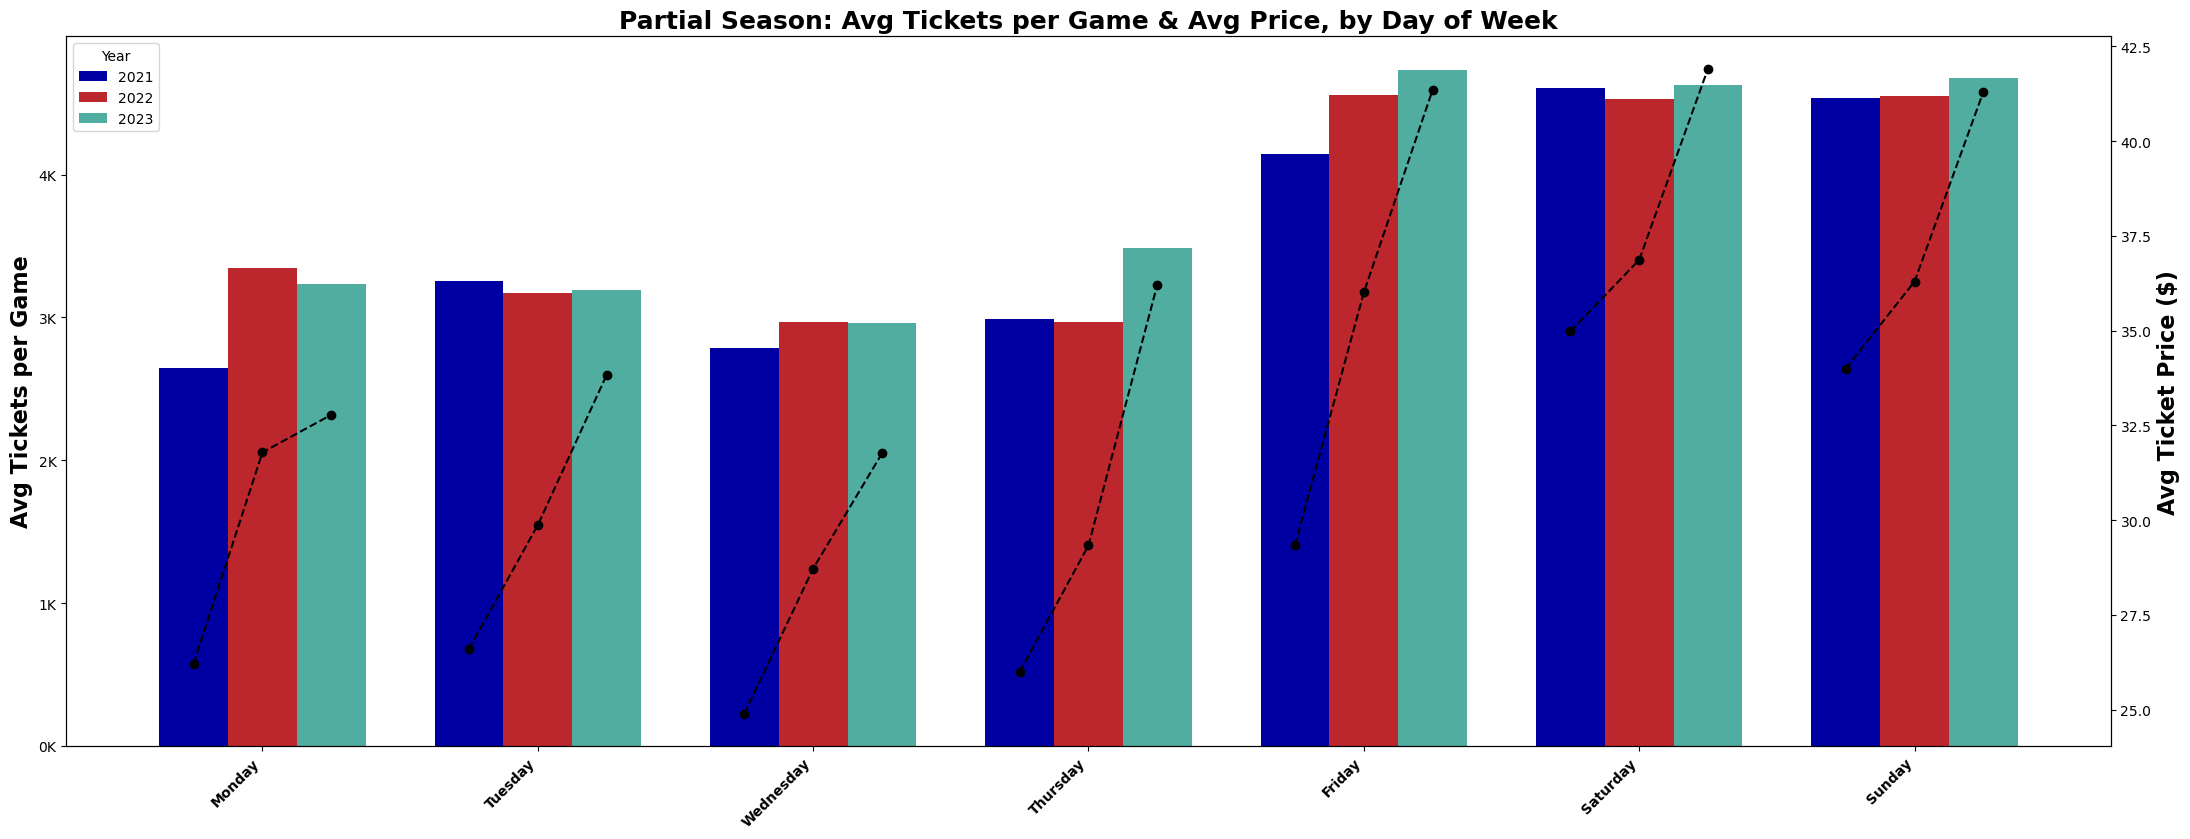

In [3]:
ticket_pivot = full.groupby(['Year', 'Day of Week'])['Partial Season Tickets (#)'].mean().unstack().reindex(columns=DOW_ORDER)
price_pivot = full.groupby(['Year', 'Day of Week'])['Partial Season Avg Price ($)'].mean().unstack().reindex(columns=DOW_ORDER)

fig, ax = plt.subplots(figsize=FIGSIZE)
x = range(len(DOW_ORDER))
for i, (year, color) in enumerate(YEAR_COLORS.items()):
    ax.bar([xi + i * BAR_WIDTH for xi in x], ticket_pivot.loc[year], width=BAR_WIDTH, label=str(year), color=color)
ax.set_title('Partial Season: Avg Tickets per Game & Avg Price, by Day of Week', **TITLE_STYLE)
ax.set_xticks([xi + BAR_WIDTH for xi in x])
ax.set_xticklabels(DOW_ORDER, rotation=45, ha='right', fontweight='bold')
ax.set_ylabel('Avg Tickets per Game', **LABEL_STYLE)
ax.yaxis.set_major_formatter(FuncFormatter(thousands_formatter))
ax.legend(title='Year', loc='upper left')

ax_price = ax.twinx()
for xi in x:
    x_points = [xi + i * BAR_WIDTH for i in range(len(YEARS))]
    y_points = [price_pivot.loc[year].iloc[xi] for year in YEARS]
    ax_price.plot(x_points, y_points, color='black', marker='o', linewidth=1.5, linestyle='dashed')
ax_price.set_ylabel('Avg Ticket Price ($)', **LABEL_STYLE)

plt.tight_layout()
plt.show()

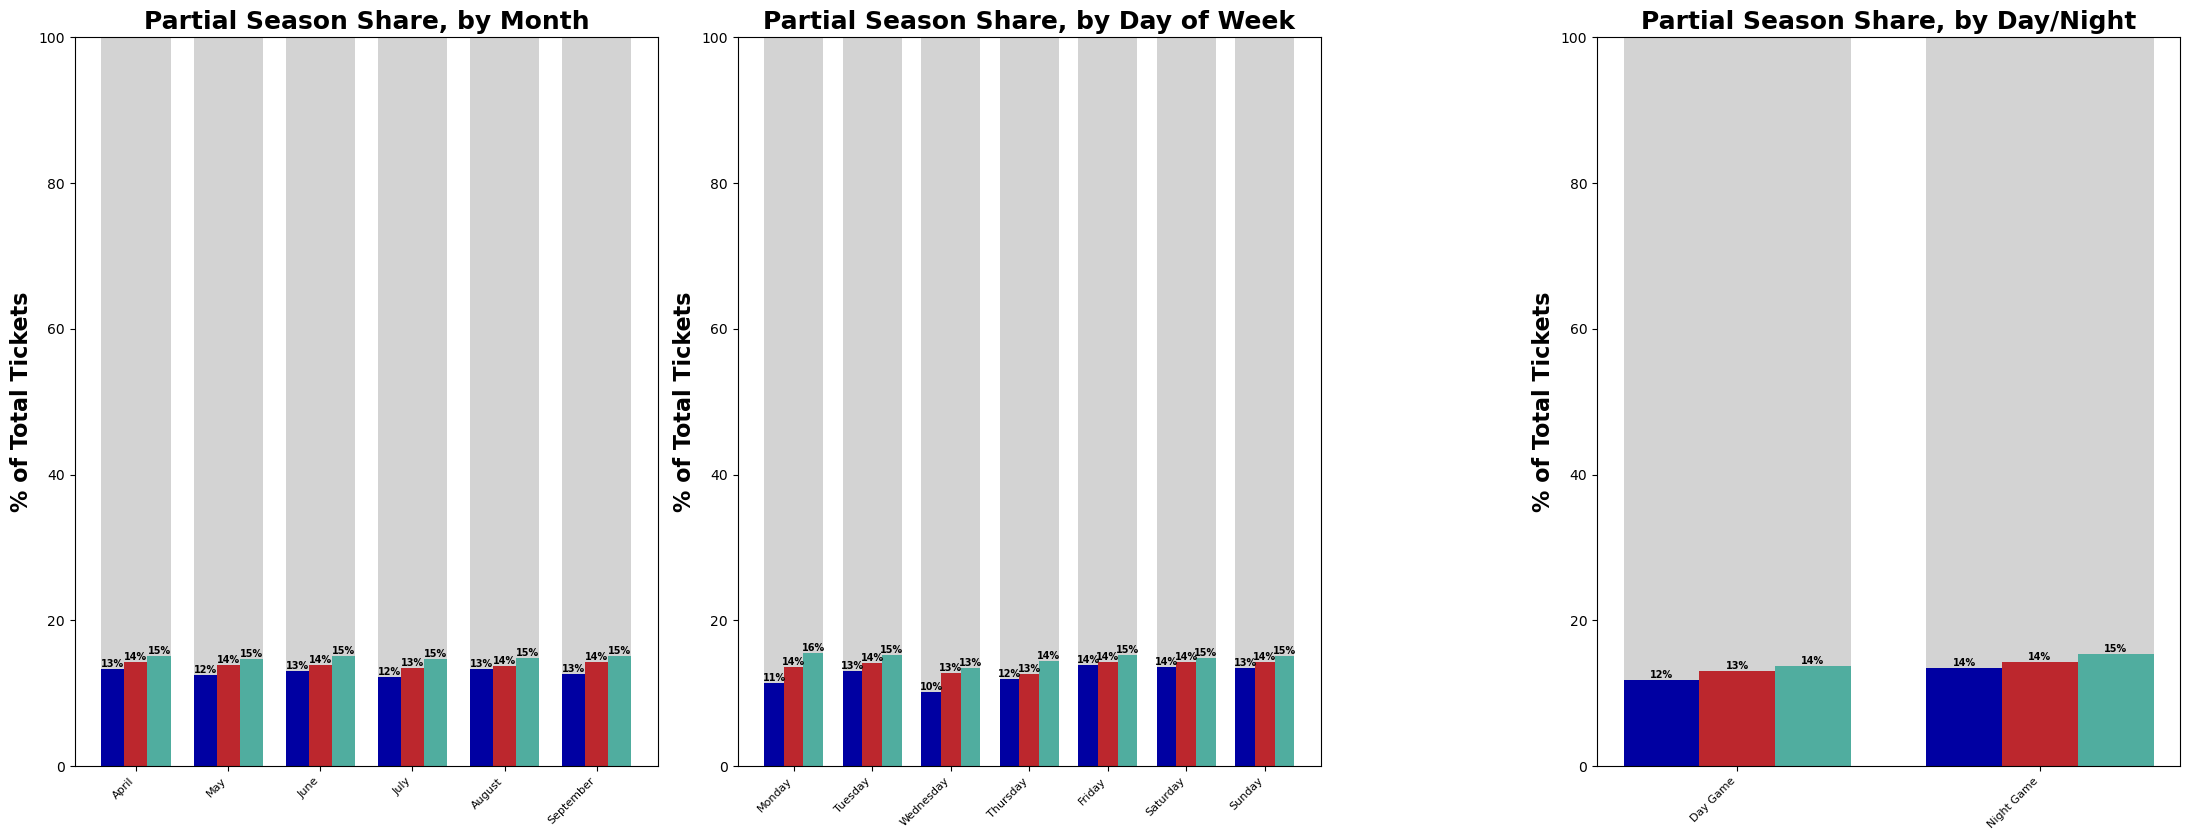

In [4]:
full['All Other Tickets (#)'] = full['Full Season Tickets (#)'] + full['Group Tickets (#)'] + full['Single Game Tickets (#)']
cuts = [
    ('Month', MONTH_ORDER),
    ('Day of Week', DOW_ORDER),
    ('Day/Night', DAYNIGHT_ORDER),
]

fig = plt.figure(figsize=FIGSIZE)
gs = fig.add_gridspec(1, 4, width_ratios=[1, 1, 0.2, 1])
ax0 = fig.add_subplot(gs[0])
ax1 = fig.add_subplot(gs[1])
ax_gap = fig.add_subplot(gs[2])
ax2 = fig.add_subplot(gs[3])
ax_gap.axis('off')

axes_list = [ax0, ax1, ax2]

for ax, (group_col, order) in zip(axes_list, cuts):
    ps_pivot = full.groupby(['Year', group_col])['Partial Season Tickets (#)'].sum().unstack().reindex(columns=order)
    other_pivot = full.groupby(['Year', group_col])['All Other Tickets (#)'].sum().unstack().reindex(columns=order)
    total_pivot = ps_pivot + other_pivot
    ps_pct = (ps_pivot / total_pivot * 100)
    other_pct = (other_pivot / total_pivot * 100)
    x = range(len(order))
    for i, year in enumerate(YEARS):
        ps_vals = ps_pct.loc[year]
        other_vals = other_pct.loc[year]
        x_pos = [xi + i * BAR_WIDTH for xi in x]
        ax.bar(x_pos, ps_vals, width=BAR_WIDTH, color=YEAR_COLORS[year])
        ax.bar(x_pos, other_vals, bottom=ps_vals, width=BAR_WIDTH, color='lightgrey')
        for xp, v in zip(x_pos, ps_vals):
            ax.text(xp, v, f'{v:.0f}%', ha='center', va='bottom', fontsize=7, fontweight='bold')
    ax.set_title(f'Partial Season Share, by {group_col}', **TITLE_STYLE)
    ax.set_xticks([xi + BAR_WIDTH for xi in x])
    ax.set_xticklabels(order, rotation=45, ha='right', fontsize=8)
    ax.set_ylabel('% of Total Tickets', **LABEL_STYLE)
    ax.set_ylim(0, 100)

plt.tight_layout()
plt.show()

**Key Findings:**
- Partial Season's share climbs every year across nearly every cut. Especially notable on Monday, Tuesday, and Wednesday because these are the three days where Single Game is collapsing fastest and where Acme has had more games added (Monday 11%->16%, Tuesday 13%->15%, Wednesday 10%->13%)
- **This growth isn't being propped up by one or two strong outlier days/months. Every month, every day of the week, and both Day and Night games all show the same steady year-over-year climb. This is a broad-based, resilient trend, not a pattern riding on a couple of favorable slots**

**Additional Notes:**
- This is the clearest evidence yet for a recommendation: committed, multi-game buyers are already steadily claiming more share on weeknights even as casual buyers abandon them. A weeknight-specific Partial Season package wouldn't be starting a new trend, it would be accelerating one that's already underway

## Grounding the Economics: What Does a Partial Season Buyer Actually Look Like?
### - Per-game pricing on weeknights vs. Single Game, and confirming the plan-size range from the data definitions

In [5]:
weeknights = ['Monday', 'Tuesday', 'Wednesday']

print("=== Partial Season Avg Price by weeknight, by year ===")
ps_price = full[full['Day of Week'].isin(weeknights)].groupby(['Year','Day of Week'])['Partial Season Avg Price ($)'].mean().unstack()[weeknights]
print(ps_price.round(2))

print("\n=== Single Game Avg Price by weeknight, by year (for comparison) ===")
sg_price = full[full['Day of Week'].isin(weeknights)].groupby(['Year','Day of Week'])['Single Game Avg Price ($)'].mean().unstack()[weeknights]
print(sg_price.round(2))

print("\n=== 2023: Partial Season vs Single Game price gap, by weeknight ===")
gap = pd.DataFrame({
    'Partial Season ($)': ps_price.loc[2023],
    'Single Game ($)': sg_price.loc[2023],
})
gap['Gap ($)'] = gap['Partial Season ($)'] - gap['Single Game ($)']
gap['Gap (%)'] = (gap['Gap ($)'] / gap['Single Game ($)'] * 100).round(1)
print(gap.round(2))

=== Partial Season Avg Price by weeknight, by year ===
Day of Week  Monday  Tuesday  Wednesday
Year                                   
2021          26.22    26.60      24.89
2022          31.79    29.87      28.72
2023          32.78    33.83      31.76

=== Single Game Avg Price by weeknight, by year (for comparison) ===
Day of Week  Monday  Tuesday  Wednesday
Year                                   
2021          14.04    14.56      20.24
2022          21.99    14.06      16.91
2023          15.88    15.53      20.11

=== 2023: Partial Season vs Single Game price gap, by weeknight ===
             Partial Season ($)  Single Game ($)  Gap ($)  Gap (%)
Day of Week                                                       
Monday                    32.78            15.88    16.89    106.4
Tuesday                   33.83            15.53    18.29    117.8
Wednesday                 31.76            20.11    11.65     57.9


### - Revenue share: is Partial Season also claiming a growing share of total dollars, not just tickets?

In [6]:
segments = {
    'Full Season': 'Full Season Revenue ($)',
    'Partial Season': 'Partial Season Revenue ($)',
    'Group': 'Group Revenue ($)',
    'Single Game': 'Single Game Revenue ($)'
}

revenue_totals = full.groupby('Year')[list(segments.values())].sum()
revenue_totals.columns = list(segments.keys())
revenue_totals['Total'] = revenue_totals.sum(axis=1)

for seg in segments.keys():
    revenue_totals[f'{seg} % of Revenue'] = (revenue_totals[seg] / revenue_totals['Total'] * 100).round(1)

print(revenue_totals[['Total'] + [f'{seg} % of Revenue' for seg in segments.keys()]])

ps_rev_pct = revenue_totals['Partial Season % of Revenue']
print(f"\nPartial Season revenue share: {ps_rev_pct[2021]}% (2021) -> {ps_rev_pct[2023]}% (2023)")
print(f"Change: {ps_rev_pct[2023]-ps_rev_pct[2021]:+.1f} percentage points")

            Total  Full Season % of Revenue  Partial Season % of Revenue  \
Year                                                                       
2021  79841409.53                      41.8                         11.5   
2022  80407348.00                      42.2                         12.9   
2023  85056446.00                      40.9                         14.2   

      Group % of Revenue  Single Game % of Revenue  
Year                                                
2021                16.0                      30.8  
2022                16.1                      28.8  
2023                16.8                      28.1  

Partial Season revenue share: 11.5% (2021) -> 14.2% (2023)
Change: +2.7 percentage points


**Key Findings:**
- Partial Season can be priced meaningfully higher than Single Game on the same weeknights, and buyers are willing to pay it
- Partial Season's revenue share is resilient compared to the rest of the portfolio.  This isn't just a volume story, it's a real, growing piece of total revenue too

**Additional Notes:**
- **Fans are willing to commit and pay more for a bundled plan regardless of day of week, which directly supports designing a weeknight-specific package rather than assuming it would need to be priced at or below Single Game levels**
- Carry into the sizing notebook: (1) Partial Season's weeknight price premium over Single Game, (2) its growing revenue share. Both are the foundation for pricing and sizing the proposal

## Partial Season: Final Thoughts & Recommendation
Partial Season is the strongest, most under-leveraged asset in Acme's ticketing portfolio and the evidence points clearly toward building a dedicated weeknight package around it, not just letting the trend continue on its own.

- **It's already winning exactly where Acme needs help.** Partial Season's share is climbing fastest on Monday, Tuesday, and Wednesday which are the same three days Single Game is collapsing on, and where Acme has had more games added. This isn't a coincidence it's a trend already in motion that a targeted package would accelerate, not create from scratch
- **The growth is broad and durable, not a fluke.** Every month, every day of the week, and both Day and Night games show the same steady year-over-year climb, showing that this is a resilient, portfolio-wide pattern, not a couple of favorable slots propping up an average
- **Fans will pay a real premium for it.** Partial Season is priced meaningfully above Single Game on the same weeknights, and buyers keep choosing it anyway, proving a weeknight-specific package doesn't need to be discounted to Single Game levels to succeed
- **It's also a genuine revenue story, not just a volume one.** Partial Season's share of total revenue is growing right alongside its ticket share

**Recommendation:** design two complementary Partial Season packages, each targeting a different growth lever:

- **3-2-1 Plan** (3 Wednesday + 2 Tuesday + 1 Monday games) is aimed at converting prior Single Game buyers abandoning Acme's worst weeknights into locked-in, committed 6-game bundle holders. This is a direct attack on the Single Game erosion problem. It doesn't reshuffle existing Partial Season buyers, it aims at getting net-new multi-game buyers who weren't previously part of that base at all.  The new 6 game package is less than a typical partial season package but may better target single game ticket fans who don't want to commit to a lot of games
- **3-6-9 Plan** (3 weekend + 6 Sunday + 9 weekday games) is built to continue growing Partial Season's own already-successful organic momentum that we confirmed earlier is broad-based and accelerating on its own. It's less a rescue play and more a bigger, more premium tier for fans already inclined toward multi-game commitment, while still recapturing some of Sunday's lapsed demand along the way.

Together, the two plans pull from different directions. One converts single-game churners into Partial Season for the first time, the other deepens Partial Season's own growth for those already leaning that way. The next step is sizing each opportunity separately. Translating lapsed Single Game demand (for 3-2-1) and Partial Season's existing growth trajectory (for 3-6-9) into realistic, phased conversion estimates, which we'll build out in the final sizing notebook.